# Stage 3 — Feature Selection
**Project:** LendingClub Loan Default Prediction  
**Methodology:** CRISP-DM  
**Notebook:** `03_feature_selection.ipynb`

---

## Purpose
Reduce 79 input features to a clean, non-redundant set before modeling.  
Every selection statistic is computed on **train data only** and the resulting  
mask is applied identically to test — no leakage, full reproducibility.

---

## Selection Strategy — Four Passes

| Pass | Method | What it removes |
|---|---|---|
| 1 | **Variance threshold** | Near-zero variance columns (near-constant OHE dummies) |
| 2 | **Pearson correlation** | One from each redundant pair with \|r\| > 0.95 |
| 3 | **Effect size review** | Cross-check Cohen's d signal rankings post-encoding |
| 4 | **Judgment calls** | Resolve `int_rate` vs `sub_grade`; confirm weak candidates |

**Cardinal rule:** All statistics are fit on `X_train` only.  
The final feature list is saved to `data/03_selected_features.json`.

---

## Artifacts Produced
| File | Contents |
|---|---|
| `data/03_selected_features.json` | Final list of retained feature names |

---
## Concept: What Feature Selection Is (and Isn't)

Feature selection at this stage is **noise removal**, not signal ranking.

We are not yet asking *which features matter most* — that is SHAP's job in Stage 7.  
We are asking *which features carry no unique information* — and removing them so the  
model's importance scores are clean and interpretable.

Three specific harms we are guarding against:

- **Redundant features** — if `funded_amnt` and `loan_amnt` are r = 0.99, they split  
  importance between them. Both look weaker than either is alone, and SHAP becomes noisy.
- **Near-constant features** — a dummy column that is 1 for only 0.02% of rows adds no  
  signal. It just adds a dimension the model has to process on every tree split.
- **Confirmed weak features** — `open_acc` had identical medians (11) in both default  
  and non-default classes in Stage 1. It is a drop candidate unless correlation analysis  
  reveals it carries unique variance not captured elsewhere.

The goal is a feature set where every remaining column **earns its place**.

---
## 0. Imports & Config

Standard library setup. `scipy.stats` is loaded here for the mutual information  
calculations in Pass 3. Plot DPI is set high for readable heatmaps.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR     = Path('data')
CLEANED_PATH = DATA_DIR / '02_cleaned.parquet'
INDICES_PATH = DATA_DIR / '02_split_indices.json'
OUTPUT_PATH  = DATA_DIR / '03_selected_features.json'

RANDOM_SEED  = 42

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

print('Libraries loaded.')
print(f'Input:  {CLEANED_PATH}')
print(f'Output: {OUTPUT_PATH}')

Libraries loaded.
Input:  data/02_cleaned.parquet
Output: data/03_selected_features.json


---
## 1. Load Data & Reconstruct Train/Test Split

We load `02_cleaned.parquet` and immediately re-split it using the saved indices  
from Stage 2. This guarantees the exact same rows in each split, regardless of  
how many times this notebook is re-run.

The `target` column is separated from features here and is **never passed to any  
selection statistic** — it only rejoins at save time to avoid any form of target leakage.

In [2]:
# ── Load cleaned parquet ──────────────────────────────────────────────────────
df = pd.read_parquet(CLEANED_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Loaded: 1,321,847 rows × 80 columns
Memory: 326.5 MB


In [3]:
df.head()

,loan_amnt,funded_amnt,term,int_rate,installment,sub_grade,emp_length,annual_inc,addr_state_default_rate,dti,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,policy_code,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,pymnt_plan_y,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_Joint App,disbursement_method_DirectPay,target
336184,9000.0000,9000.0000,0,6.9200,277.5700,4,11.0000,80000.0000,0.1741,12.4400,695.0000,699.0000,0.0000,8.0000,0.0000,18618.0000,70.3000,30.0000,0.0000,1.0000,0.0000,0.0000,343647.0000,26500.0000,4.0000,42956.0000,6082.0000,75.4000,0.0000,0.0000,...,0.0000,363781.0000,80795.0000,24700.0000,64379.0000,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2235718,3000.0000,3000.0000,0,11.4900,98.9200,10,11.0000,100000.0000,0.1814,15.1300,690.0000,694.0000,0.0000,15.0000,0.0000,8479.0000,41.6000,32.0000,0.0000,1.0000,0.0000,0.0000,156410.0000,20400.0000,6.0000,10427.0000,3474.0000,44.9000,0.0000,0.0000,...,0.0000,207734.0000,28653.0000,6300.0000,27334.0000,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1078118,10000.0000,10000.0000,1,16.2900,244.7300,16,4.0000,80000.0000,0.1808,9.8300,665.0000,669.0000,0.0000,15.0000,1.0000,21218.0000,78.3000,23.0000,0.0000,1.0000,0.0000,0.0000,203066.0000,27100.0000,9.0000,16922.0000,245.0000,91.8000,0.0000,0.0000,...,0.0000,229441.0000,28213.0000,3000.0000,12322.0000,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
158753,32000.0000,32000.0000,0,9.9900,1032.4000,8,11.0000,120000.0000,0.1567,17.6500,680.0000,684.0000,1.0000,11.0000,0.0000,17714.0000,65.0000,27.0000,0.0000,1.0000,0.0000,0.0000,320746.0000,27400.0000,4.0000,29158.0000,5900.0000,64.0000,0.0000,0.0000,...,0.0000,369079.0000,107990.0000,23600.0000,106988.0000,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1122213,20000.0000,20000.0000,0,7.4900,622.0400,4,3.0000,125000.0000,0.1856,0.9100,770.0000,774.0000,0.0000,4.0000,0.0000,4353.0000,15.9000,10.0000,0.0000,1.0000,0.0000,0.0000,5045.0000,27300.0000,0.0000,1261.0000,22947.0000,15.9000,0.0000,0.0000,...,0.0000,35782.0000,5045.0000,27300.0000,0.0000,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [4]:
# ── Reconstruct train/test split from saved indices ───────────────────────────
with open(INDICES_PATH) as f:
    split = json.load(f)

train_idx = split['train_indices']
test_idx  = split['test_indices']

# ── Separate features from target ─────────────────────────────────────────────
FEATURE_COLS = [c for c in df.columns if c != 'target']

X_train = df.loc[train_idx, FEATURE_COLS].reset_index(drop=True)
X_test  = df.loc[test_idx,  FEATURE_COLS].reset_index(drop=True)
y_train = df.loc[train_idx, 'target'].reset_index(drop=True)
y_test  = df.loc[test_idx,  'target'].reset_index(drop=True)

# ── Free the full dataframe — no longer needed ────────────────────────────────
del df

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Train default rate: {y_train.mean():.4f}')
print(f'Test default rate:  {y_test.mean():.4f}')
print(f'\nFeatures entering selection: {X_train.shape[1]}')

X_train: (1057477, 79)  |  X_test: (264370, 79)
Train default rate: 0.1722
Test default rate:  0.1722

Features entering selection: 79


### ✦ Interpretation

Confirm three things before proceeding:

- **Default rates ≈ 0.1722** in both train and test — confirms stratification held.
- **Feature count = 79** — if different, investigate the Stage 2 save step.
- **Train ≈ 1,057,477 rows | Test ≈ 264,370 rows** — confirms 80/20 split integrity.

If all three match, the data pipeline is intact and selection can proceed.

---
## Pass 1 — Variance Threshold

### Concept

A **variance threshold** removes columns that are nearly constant across all rows.  
The intuition is simple: if a column is 0 for 99.8% of rows, it has almost no power  
to differentiate defaulters from non-defaulters. It's not useful signal — it's noise  
that wastes a tree split.

This primarily catches **one-hot encoded dummy columns** where the underlying category  
is very rare. For example, `disbursement_method_DirectPay` might apply to only 0.01%  
of loans — almost always 0, rarely 1.

**Threshold choice:** We use `variance < 0.001`.  
For a binary column, variance = p × (1 − p). A variance of 0.001 corresponds to  
a column that is 1 for roughly 0.1% of rows — far too rare to be useful.

We compute variance **on X_train only**, then drop the same columns from X_test.

In [5]:
# ── Compute variance of every column on train only ────────────────────────────
VARIANCE_THRESHOLD = 0.001

train_variance = X_train.var()

low_var_cols = train_variance[train_variance < VARIANCE_THRESHOLD].index.tolist()

print(f'Variance threshold: {VARIANCE_THRESHOLD}')
print(f'Columns below threshold: {len(low_var_cols)}')
print()

if low_var_cols:
    low_var_df = pd.DataFrame({
        'column':   low_var_cols,
        'variance': train_variance[low_var_cols].values,
        'pct_ones': X_train[low_var_cols].mean().values * 100
    }).sort_values('variance')
    print(low_var_df.to_string(index=False))
else:
    print('No columns below threshold — all features have sufficient variance.')

Variance threshold: 0.001
Columns below threshold: 8

                  column  variance  pct_ones
             policy_code    0.0000  100.0000
     home_ownership_NONE    0.0000    0.0038
            pymnt_plan_y    0.0001    0.0128
    home_ownership_OTHER    0.0001    0.0130
 addr_state_default_rate    0.0003   17.2152
     purpose_educational    0.0003    0.0335
purpose_renewable_energy    0.0007    0.0661
        num_tl_120dpd_2m    0.0009    0.0793


In [6]:
# ── Drop low-variance columns from both train and test ────────────────────────
# Same mask applied to both — test never influences the drop decision.
X_train.drop(columns=low_var_cols, inplace=True)
X_test.drop(columns=low_var_cols,  inplace=True)

# ── Track drops for the final summary ─────────────────────────────────────────
dropped_variance = low_var_cols.copy()

print(f'Dropped {len(dropped_variance)} low-variance columns.')
print(f'Features remaining: {X_train.shape[1]}')

Dropped 8 low-variance columns.
Features remaining: 71


### ✦ Interpretation

Any dropped columns here are OHE dummies for extremely rare categories.  
Their rarity means they would appear in almost no training examples — the model  
cannot learn a reliable split from them, so keeping them only adds dimension.

If 0 columns are dropped: all 26 OHE dummies represent categories with at least  
0.1% prevalence, which is reasonable — no action needed.

If columns are dropped: check the `pct_ones` column above. Anything below ~0.1%  
is correctly removed. Anything between 0.1–1% is borderline — note it but keep  
the threshold as-is for now.

---
## Pass 2 — Pearson Correlation (Redundancy Removal)

### Concept

**Pearson correlation** measures the linear relationship between two continuous  
features. A value of r = 1.0 means the two columns move in perfect lockstep —  
they contain identical information.

When two features are highly correlated (say r > 0.95), keeping both causes:  
1. **Split importance dilution** — XGBoost splits importance across both columns,  
   making each look weaker than it actually is.
2. **Unstable SHAP values** — highly correlated features compete for attribution,  
   producing noisy, hard-to-interpret SHAP plots.
3. **Wasted computation** — two columns doing the same job.

**Our threshold: |r| > 0.95.**  
When a pair exceeds this, we drop the one with **lower mean absolute correlation  
to all other features** — i.e., the one that is more substitutable.

**Known pairs to watch:**
- `loan_amnt` vs `funded_amnt` — expected ~0.99 (near-identical at origination)
- `int_rate` vs `sub_grade` — expected ~0.95–0.97 (both encode LC's risk model)
- `installment` vs `loan_amnt` — moderate correlation expected (~0.85) but not redundant

Correlation is computed on **X_train only**.

In [7]:
# ── Compute full Pearson correlation matrix on train ──────────────────────────
# Using float32 throughout — no upcasting needed, saves memory.
print('Computing correlation matrix on X_train...')
corr_matrix = X_train.corr(method='pearson').astype('float32')
print(f'Correlation matrix shape: {corr_matrix.shape}')

Computing correlation matrix on X_train...
Correlation matrix shape: (71, 71)


In [8]:
# ── Extract all pairs with |r| > 0.95 ────────────────────────────────────────
CORR_THRESHOLD = 0.95

# Upper triangle only — avoids counting each pair twice and excludes self-correlation
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find pairs exceeding threshold
high_corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'correlation'})
)
high_corr_pairs = high_corr_pairs[
    high_corr_pairs['correlation'].abs() >= CORR_THRESHOLD
].sort_values('correlation', ascending=False)

print(f'Pairs with |r| >= {CORR_THRESHOLD}: {len(high_corr_pairs)}')
print()
if len(high_corr_pairs) > 0:
    print(high_corr_pairs.to_string(index=False))

Pairs with |r| >= 0.95: 6

      feature_a           feature_b  correlation
 fico_range_low     fico_range_high       1.0000
      loan_amnt         funded_amnt       0.9995
num_actv_rev_tl num_rev_tl_bal_gt_0       0.9831
       open_acc            num_sats       0.9822
       int_rate           sub_grade       0.9778
    tot_cur_bal     tot_hi_cred_lim       0.9717


### ✦ Interpretation — High-Correlation Pairs

**What to expect and why:**

- **`loan_amnt` vs `funded_amnt`** (expected r ≈ 0.99):  
  `loan_amnt` is what the borrower requested. `funded_amnt` is what investors actually  
  funded. In most cases they match. The small difference carries negligible signal  
  compared to the redundancy cost. **Keep `loan_amnt`** (the origination request) as  
  it is the more meaningful causal variable at application time.

- **`int_rate` vs `sub_grade`** (expected r ≈ 0.95–0.97):  
  Both are LC's own risk assessments. `sub_grade` is an ordinal risk bucket (A1–G5).  
  `int_rate` is the rate assigned based on that grade plus market conditions.  
  They are highly correlated but not identical — `int_rate` also varies with loan term  
  and vintage. See the dedicated analysis cell below before deciding.

- **Any other pairs** are bonus findings. Apply the same drop logic: remove the column  
  with higher mean absolute correlation to the rest of the feature set (more substitutable).

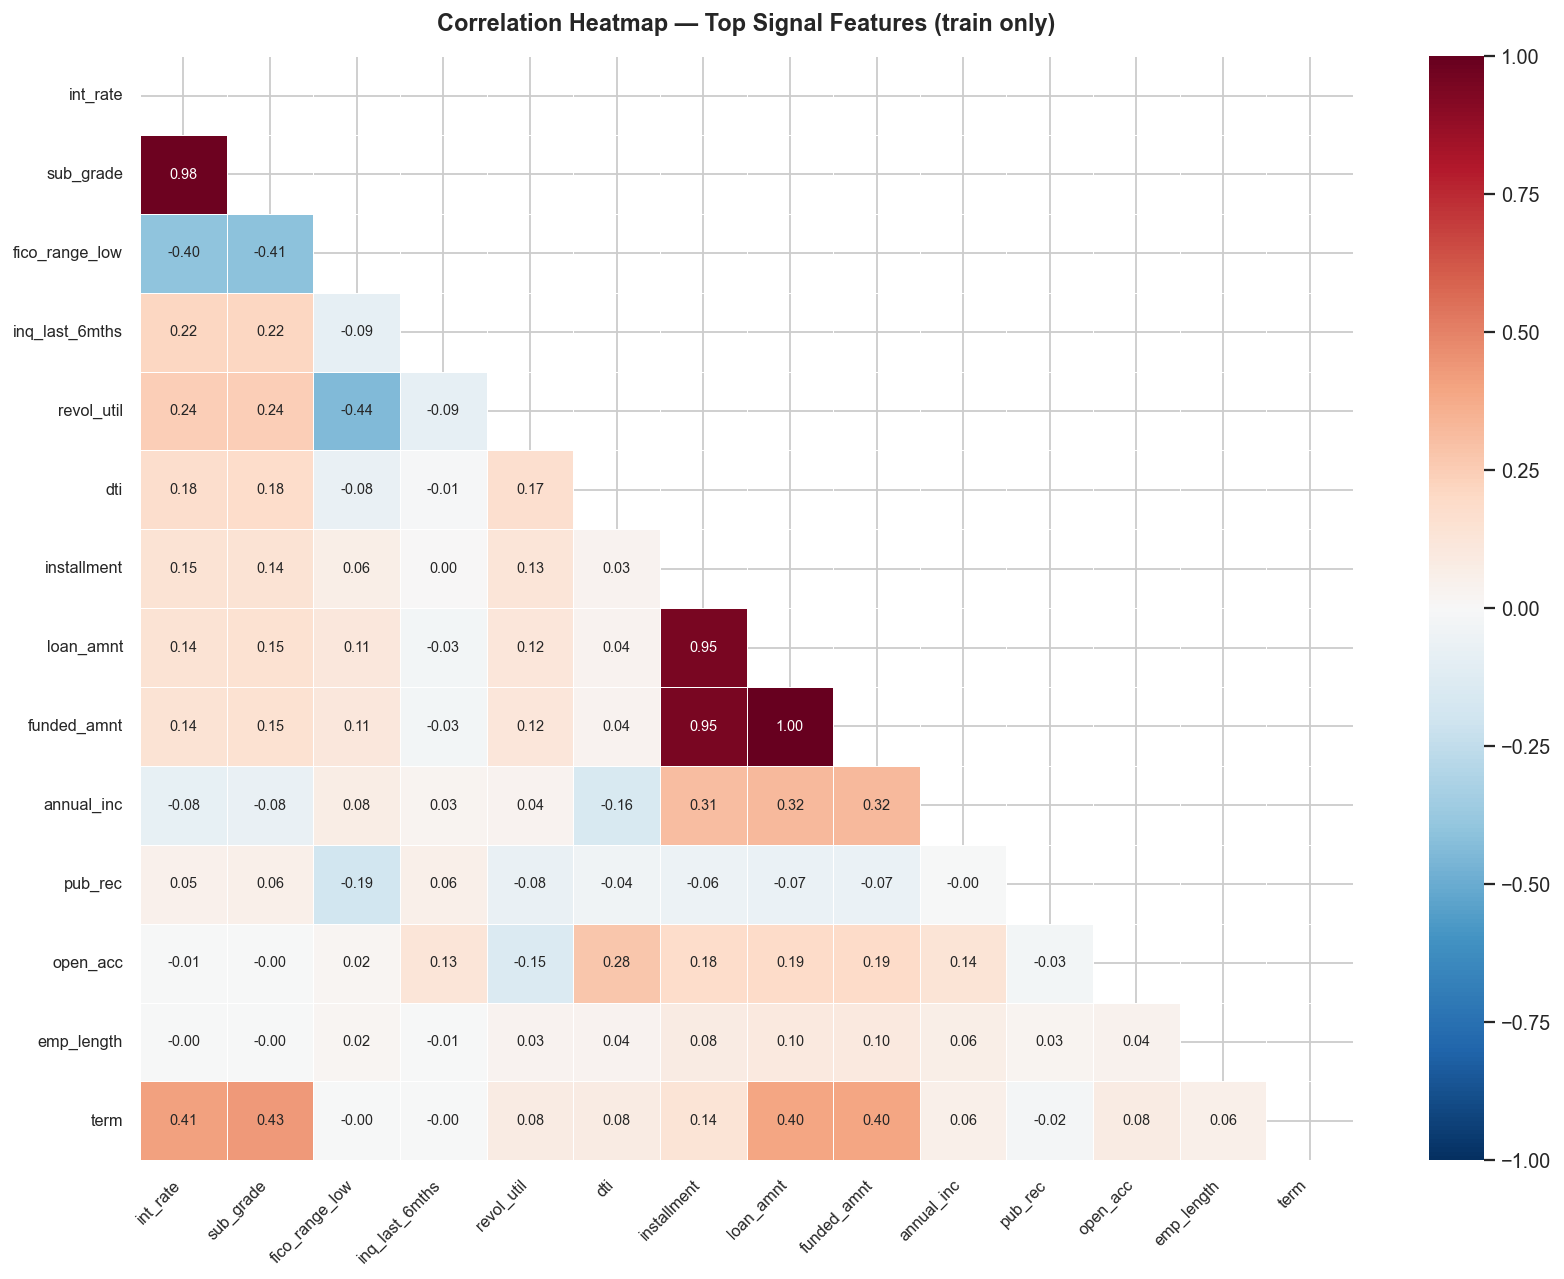

In [10]:
# ── Heatmap: focused on known candidate pairs + top Cohen's d features ────────
# A full 71×71 heatmap is unreadable. We show only the 15 most informative features
# based on Stage 1 effect size rankings plus the known redundancy candidates.

focus_features = [
    'int_rate', 'sub_grade', 'fico_range_low', 'inq_last_6mths',
    'revol_util', 'dti', 'installment', 'loan_amnt', 'funded_amnt',
    'annual_inc', 'pub_rec', 'open_acc', 'addr_state_default_rate',
    'emp_length', 'term'
]

# Keep only features that survived variance pass
focus_features = [f for f in focus_features if f in X_train.columns]

focus_corr = corr_matrix.loc[focus_features, focus_features]

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(focus_corr, dtype=bool))

sns.heatmap(
    focus_corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title(
    'Correlation Heatmap — Top Signal Features (train only)',
    fontsize=13, fontweight='bold', pad=14
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/03_Correlation_Heatmap', dpi = 150, bbox_inches ='tight')
plt.show()

### ✦ Interpretation — Correlation Heatmap

**How to read this:** Each cell shows the Pearson r between two features.  
Dark red = strong positive correlation. Dark blue = strong negative. White = near-zero.

**What to look for:**

- **`loan_amnt` / `funded_amnt` block** — should be deep red (r ≈ 0.99).  
  This confirms the drop decision: remove `funded_amnt`.

- **`int_rate` / `sub_grade` block** — should be deep red (r ≈ 0.95–0.97).  
  This is the most important decision in this stage — see the dedicated analysis below.

- **`installment` / `loan_amnt`** — likely moderate positive correlation (~0.8–0.9).  
  They are related (bigger loan = higher payment) but not redundant — installment  
  also encodes loan term and interest rate. Keep both unless r > 0.95.

- **`fico_range_low` / `int_rate`** — expect moderate negative correlation (~−0.6 to −0.7).  
  Higher FICO → lower rate. This is expected domain knowledge, not a reason to drop either.

- **`dti` / `annual_inc`** — expect weak to moderate negative (~−0.1 to −0.3).  
  High income borrowers tend to have lower debt-to-income. Not redundant — both stay.

---
### Deep Dive: `int_rate` vs `sub_grade`

This is the most consequential decision in Stage 3. Here is the context:

**`sub_grade`** is LendingClub's internal risk classification — A1 (safest) to G5  
(riskiest), encoded as ordinal integers 1–35. It reflects LC's underwriting model  
at application time.

**`int_rate`** is the annual interest rate assigned to the loan. It is determined  
primarily by `sub_grade`, but also varies with loan term (60-month loans carry  
a premium) and the vintage year (rates shift with the Fed funds rate).

**Why this matters:**  
In Stage 1, `int_rate` had the highest Cohen's d of all features (d = 0.6216).  
It is the single strongest individual predictor of default. If we drop it in favor  
of `sub_grade`, we sacrifice measurable signal.

**The decision framework:**

| Scenario | If r < 0.97 | If r ≥ 0.97 |
|---|---|---|
| Action | Keep both | Keep `int_rate`, drop `sub_grade` |
| Reason | Enough unique variance in each | `int_rate` dominates; `sub_grade` is redundant |

We compute the exact r below and apply this rule programmatically.

In [11]:
# ── Examine int_rate vs sub_grade directly ────────────────────────────────────
r_int_sub = corr_matrix.loc['int_rate', 'sub_grade']
print(f'Pearson r  int_rate vs sub_grade: {r_int_sub:.4f}')
print()

# ── Default rate by sub_grade bucket (train only) ─────────────────────────────
# This shows whether sub_grade adds any non-linear signal that int_rate misses.
subgrade_analysis = pd.DataFrame({
    'sub_grade':     X_train['sub_grade'],
    'int_rate':      X_train['int_rate'],
    'default':       y_train
})

subgrade_summary = (
    subgrade_analysis
    .groupby('sub_grade')
    .agg(
        n          = ('default', 'count'),
        default_rate = ('default', 'mean'),
        mean_int_rate = ('int_rate', 'mean')
    )
    .reset_index()
)

print('Default rate and mean int_rate by sub_grade (1=A1, 35=G5):')
print(subgrade_summary.to_string(index=False))

Pearson r  int_rate vs sub_grade: 0.9778

Default rate and mean int_rate by sub_grade (1=A1, 35=G5):
 sub_grade     n  default_rate  mean_int_rate
         1 33316        0.0287         5.5354
         2 26480        0.0433         6.5131
         3 26794        0.0505         7.1474
         4 39445        0.0624         7.5273
         5 49115        0.0746         8.2158
         6 55671        0.0898         8.8012
         7 58078        0.0996         9.8328
         8 65756        0.1118        10.6936
         9 67634        0.1279        11.4747
        10 64196        0.1426        11.9604
        11 67946        0.1583        12.7088
        12 63157        0.1754        13.3604
        13 60269        0.1872        13.9495
        14 59928        0.2065        14.5797
        15 51174        0.2167        15.3936
        16 41121        0.2364        16.2294
        17 35405        0.2514        17.0997
        18 30005        0.2605        17.7027
        19 28835        0

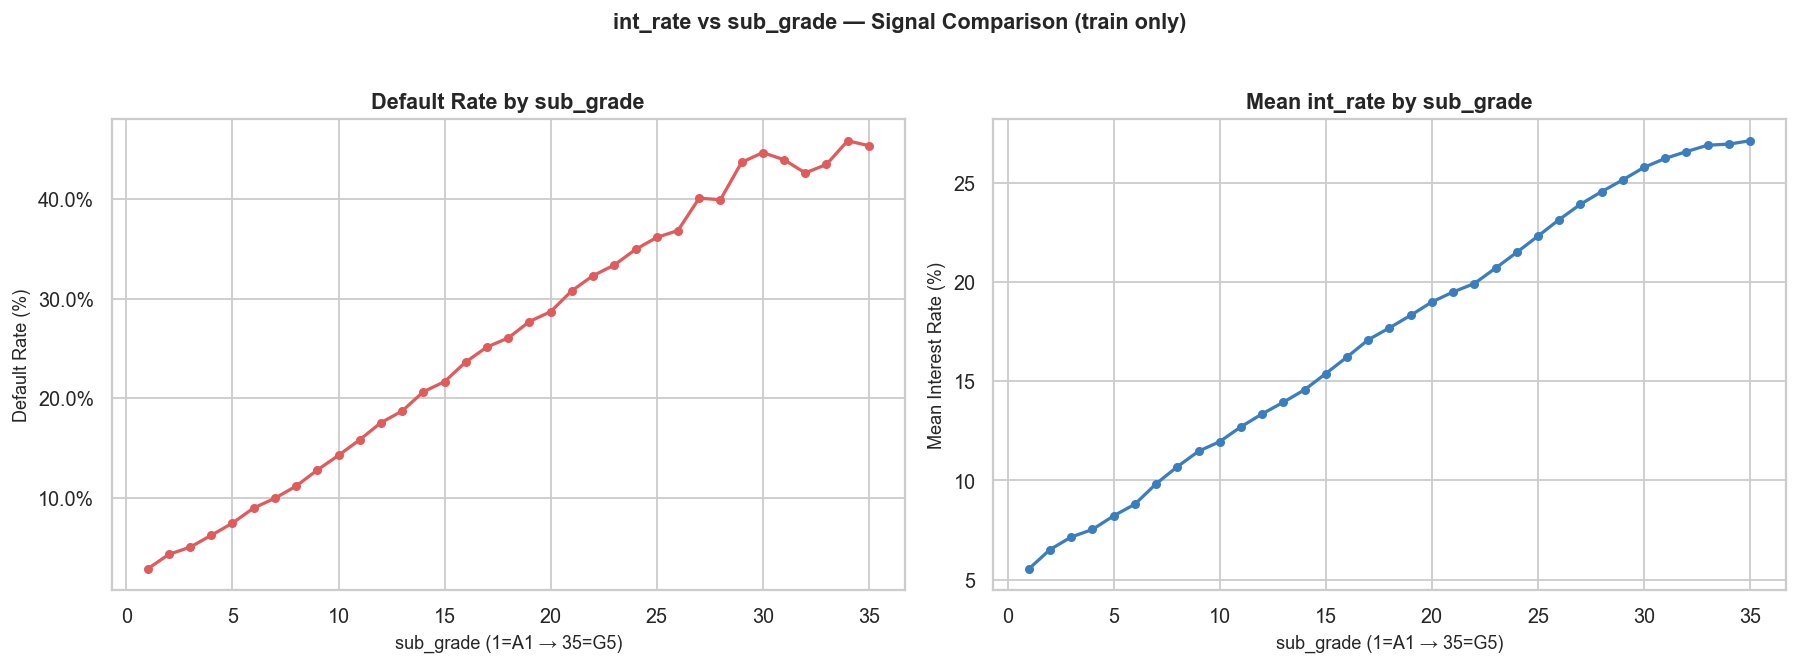

In [13]:
# ── Visualise: default rate vs sub_grade colored by int_rate ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: default rate by sub_grade
axes[0].plot(subgrade_summary['sub_grade'],
             subgrade_summary['default_rate'] * 100,
             marker='o', markersize=4, color='#e05c5c', linewidth=1.8)
axes[0].set_xlabel('sub_grade (1=A1 → 35=G5)', fontsize=10)
axes[0].set_ylabel('Default Rate (%)', fontsize=10)
axes[0].set_title('Default Rate by sub_grade', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# Right: mean int_rate by sub_grade
axes[1].plot(subgrade_summary['sub_grade'],
             subgrade_summary['mean_int_rate'],
             marker='o', markersize=4, color='#3a7ebf', linewidth=1.8)
axes[1].set_xlabel('sub_grade (1=A1 → 35=G5)', fontsize=10)
axes[1].set_ylabel('Mean Interest Rate (%)', fontsize=10)
axes[1].set_title('Mean int_rate by sub_grade', fontweight='bold')

plt.suptitle('int_rate vs sub_grade — Signal Comparison (train only)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/03_int_rate_vs_subgrade_signal_compare', dpi = 150, bbox_inches='tight')
plt.show()

### ✦ Interpretation — int_rate vs sub_grade

**Both plots should show the same near-monotonic upward trend** — confirming that  
int_rate and sub_grade are encoding nearly identical information.

**How to apply the decision rule:**

- If r ≥ 0.97: drop `sub_grade`, keep `int_rate`.  
  Rationale: int_rate had the highest effect size (d = 0.62) and is a continuous  
  feature — it carries more gradient information than a 35-level ordinal bucket.

- If r < 0.97: keep both.  
  Rationale: enough unique variance remains in sub_grade (possibly from within-grade  
  rate variation across vintages) that dropping it costs real signal.

**What the two plots tell you:**  
If the default rate curve (left) tracks almost perfectly with the int_rate curve (right),  
then sub_grade is not adding anything beyond what int_rate already captures.  
Any divergence between the two curves is evidence that sub_grade retains unique signal.

In [14]:
# ── Programmatic drop decision for all high-correlation pairs ─────────────────
# Rule: for each pair |r| > 0.95, drop the feature with higher mean absolute
# correlation to all other features (the more substitutable one).
# Exception: int_rate vs sub_grade uses the threshold r >= 0.97 rule above.

dropped_correlation = []

# Mean absolute correlation to all other features (substitutability score)
mean_abs_corr = corr_matrix.abs().mean()

# Track which columns have already been scheduled for dropping
scheduled_drop = set()

for _, row in high_corr_pairs.iterrows():
    a, b = row['feature_a'], row['feature_b']
    r    = row['correlation']

    # Skip if either already dropped
    if a in scheduled_drop or b in scheduled_drop:
        continue

    # Special rule: int_rate vs sub_grade
    if set([a, b]) == {'int_rate', 'sub_grade'}:
        if abs(r) >= 0.97:
            scheduled_drop.add('sub_grade')
            print(f'[int_rate vs sub_grade] r={r:.4f} >= 0.97 → DROP sub_grade, keep int_rate')
        else:
            print(f'[int_rate vs sub_grade] r={r:.4f} < 0.97 → KEEP BOTH')
        continue

    # General rule: drop whichever is more substitutable (higher mean abs corr)
    drop_col = a if mean_abs_corr[a] >= mean_abs_corr[b] else b
    keep_col = b if drop_col == a else a
    scheduled_drop.add(drop_col)
    print(f'[r={r:.4f}] DROP {drop_col}  (mean_abs_corr={mean_abs_corr[drop_col]:.4f})'
          f'  →  keep {keep_col}')

dropped_correlation = list(scheduled_drop)
print(f'\nTotal columns to drop from correlation pass: {len(dropped_correlation)}')
print(f'Columns: {dropped_correlation}')

[r=1.0000] DROP fico_range_low  (mean_abs_corr=0.1324)  →  keep fico_range_high
[r=0.9995] DROP funded_amnt  (mean_abs_corr=0.1620)  →  keep loan_amnt
[r=0.9831] DROP num_actv_rev_tl  (mean_abs_corr=0.1745)  →  keep num_rev_tl_bal_gt_0
[r=0.9822] DROP open_acc  (mean_abs_corr=0.1979)  →  keep num_sats
[int_rate vs sub_grade] r=0.9778 >= 0.97 → DROP sub_grade, keep int_rate
[r=0.9717] DROP tot_hi_cred_lim  (mean_abs_corr=0.1772)  →  keep tot_cur_bal

Total columns to drop from correlation pass: 6
Columns: ['num_actv_rev_tl', 'fico_range_low', 'sub_grade', 'open_acc', 'funded_amnt', 'tot_hi_cred_lim']


In [15]:
# ── Apply correlation drops to both train and test ────────────────────────────
X_train.drop(columns=dropped_correlation, inplace=True)
X_test.drop(columns=dropped_correlation,  inplace=True)

print(f'Dropped {len(dropped_correlation)} correlated columns.')
print(f'Features remaining: {X_train.shape[1]}')

Dropped 6 correlated columns.
Features remaining: 65


---
## Pass 3 — Effect Size Review (Cohen's d)

### Concept

**Cohen's d** measures how separated the default and non-default distributions  
are for a given feature. A large d means the two classes look very different on  
that feature — strong signal. A near-zero d means the feature's distribution is  
nearly identical in both classes — weak signal.

Formula:  
`d = (mean_default − mean_nondefault) / pooled_std`

We are re-computing Cohen's d here on the **post-encoding feature set** — the Stage 1  
rankings were computed on raw features before OHE and target encoding. Some features  
may rank differently now.

**Purpose of this pass:**  
- Confirm the top features still have strong signal post-encoding  
- Flag any features with d < 0.02 as drop candidates  
- Cross-check `open_acc` (Stage 1 concern: identical median in both classes)

We will not drop aggressively here — only features with near-zero effect size  
AND no domain justification.

In [16]:
# ── Compute Cohen's d for all remaining features ──────────────────────────────
# Computed on train only.
defaults    = X_train[y_train == 1]
nondefaults = X_train[y_train == 0]

results = []
for col in X_train.columns:
    d1 = defaults[col].values.astype('float32')
    d0 = nondefaults[col].values.astype('float32')

    mean_diff   = d1.mean() - d0.mean()
    pooled_std  = np.sqrt((d1.std()**2 + d0.std()**2) / 2)

    # Avoid division by zero for near-constant columns
    cohens_d = mean_diff / pooled_std if pooled_std > 1e-6 else 0.0

    results.append({
        'feature':   col,
        'cohens_d':  abs(cohens_d),
        'mean_default':    d1.mean(),
        'mean_nondefault': d0.mean()
    })

effect_df = (
    pd.DataFrame(results)
    .sort_values('cohens_d', ascending=False)
    .reset_index(drop=True)
)

print(f'Effect size computed for {len(effect_df)} features.')
print(f'\nTop 20 features by Cohen\'s d:')
print(effect_df.head(20).to_string(index=False))

Effect size computed for 65 features.

Top 20 features by Cohen's d:
                     feature  cohens_d  mean_default  mean_nondefault
                    int_rate    0.6266       15.5263          12.6887
             fico_range_high    0.3444      690.9576         700.7692
                        term    0.3091        0.4043           0.2605
        acc_open_past_24mths    0.2880        5.2878           4.3743
                         dti    0.2204       20.0731          18.0220
              bc_open_to_buy    0.2088     7046.9121        9777.6318
              total_bc_limit    0.2024    17956.9219       21932.7754
                 avg_cur_bal    0.1989    10656.1729       13533.0342
              inq_last_6mths    0.1834        0.8034           0.6201
                 tot_cur_bal    0.1760   116619.7578      141934.5000
              mo_sin_rcnt_tl    0.1736        6.7777           8.2245
       mo_sin_rcnt_rev_tl_op    0.1634       11.0699          13.5928
                    m

In [17]:
# ── Inspect bottom of the ranking — drop candidates ───────────────────────────
EFFECT_SIZE_FLOOR = 0.02

weak_features = effect_df[effect_df['cohens_d'] < EFFECT_SIZE_FLOOR]

print(f'Features with Cohen\'s d < {EFFECT_SIZE_FLOOR}: {len(weak_features)}')
print()
if len(weak_features) > 0:
    print(weak_features[['feature', 'cohens_d', 'mean_default', 'mean_nondefault']]
          .to_string(index=False))
else:
    print('No features below the effect size floor.')

Features with Cohen's d < 0.02: 19

                   feature  cohens_d  mean_default  mean_nondefault
    purpose_major_purchase    0.0187        0.0187           0.0214
            purpose_moving    0.0174        0.0077           0.0063
             num_rev_accts    0.0162       14.7110          14.5830
             purpose_house    0.0151        0.0051           0.0041
           purpose_wedding    0.0143        0.0013           0.0019
                 num_bc_tl    0.0130        8.0413           8.1022
            pct_tl_nvr_dlq    0.0124       94.1630          94.2694
                 tax_liens    0.0119        0.0608           0.0559
             purpose_other    0.0108        0.0562           0.0537
total_il_high_credit_limit    0.0097    41342.2031       41745.1367
           purpose_medical    0.0081        0.0113           0.0104
        home_ownership_OWN    0.0072        0.1080           0.1058
  chargeoff_within_12_mths    0.0067        0.0096           0.0088
            

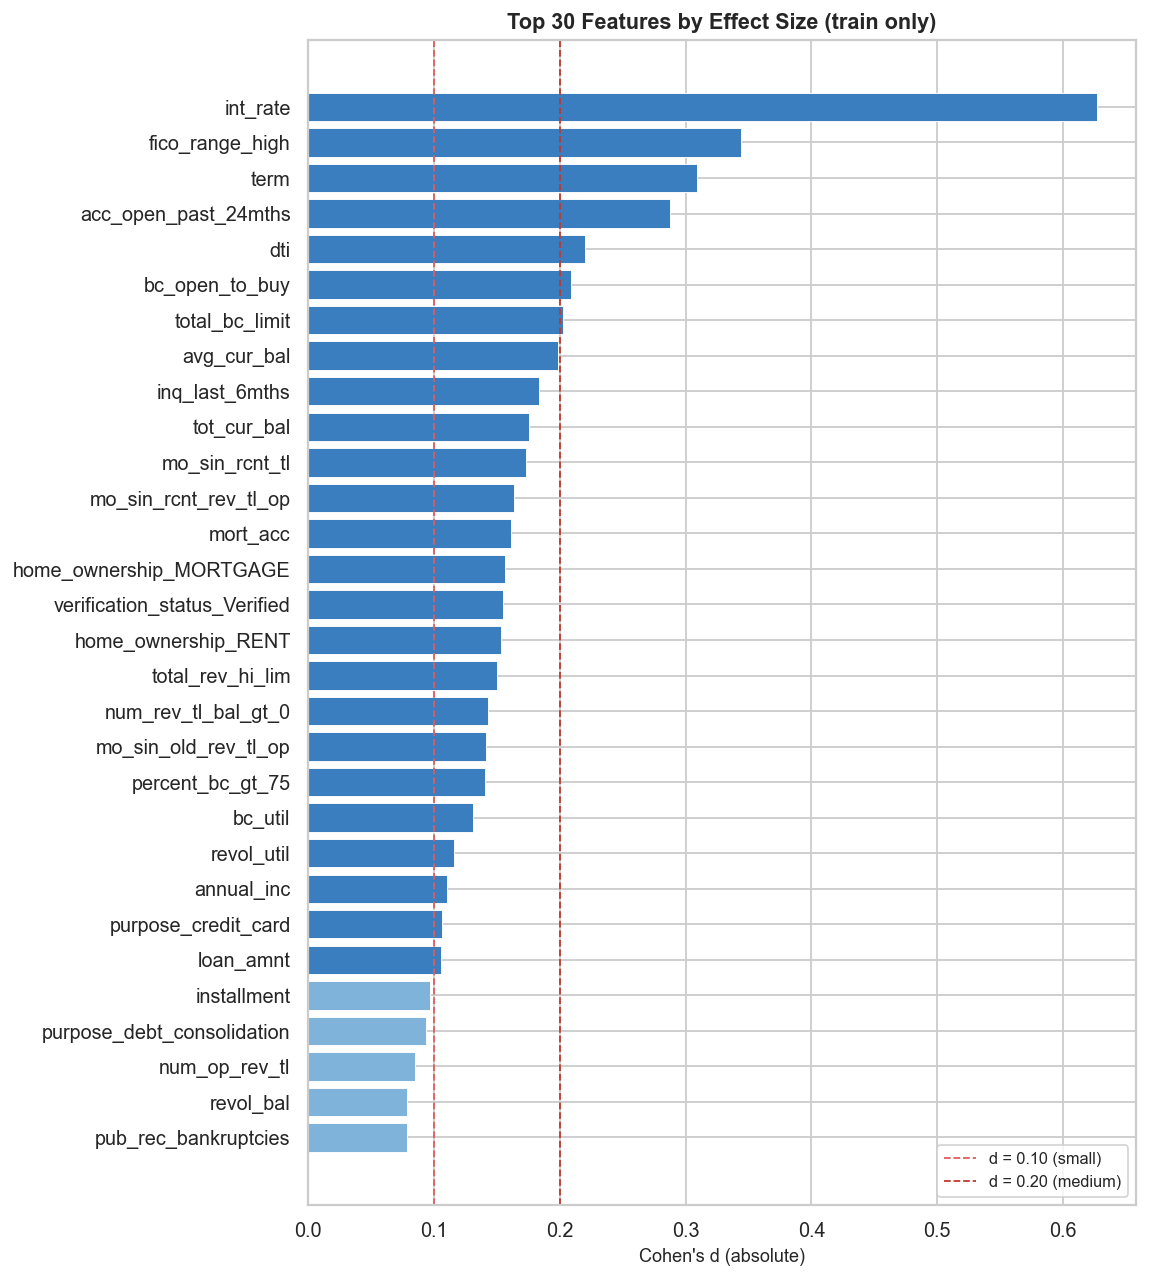

In [18]:
# ── Bar chart: top 30 features by Cohen's d ───────────────────────────────────
top30 = effect_df.head(30).sort_values('cohens_d')

fig, ax = plt.subplots(figsize=(9, 10))

bars = ax.barh(
    top30['feature'],
    top30['cohens_d'],
    color=[
        '#3a7ebf' if d >= 0.10 else
        '#7fb3d9' if d >= 0.05 else
        '#c6daec'
        for d in top30['cohens_d']
    ],
    edgecolor='white',
    linewidth=0.5
)

# Reference lines
ax.axvline(0.10, color='#e05c5c', linestyle='--', linewidth=1.0, label='d = 0.10 (small)')
ax.axvline(0.20, color='#c0392b', linestyle='--', linewidth=1.0, label='d = 0.20 (medium)')

ax.set_xlabel("Cohen's d (absolute)", fontsize=10)
ax.set_title('Top 30 Features by Effect Size (train only)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/top_30_features_by_effect_size', dpi =150, bbox_inches ='tight')
plt.show()

### ✦ Interpretation — Effect Size Rankings

**Cohen's d benchmarks:**
- d ≥ 0.20 → medium effect — meaningful separation between classes
- d 0.10–0.20 → small but useful effect
- d < 0.05 → weak — borderline drop candidate
- d < 0.02 → negligible — strong drop candidate

**Expected top features (from Stage 1):**

| Feature | Stage 1 d | What it means in lending |
|---|---|---|
| `int_rate` | 0.6216 | Highest rate loans are highest risk — LC already knows this |
| `fico_range_low` | 0.3968 | Credit score is the oldest predictor in lending |
| `inq_last_6mths` | 0.2415 | Recent credit applications → financial stress signal |
| `revol_util` | 0.1898 | High revolving utilization → borrower is stretched thin |
| `dti` | 0.1134 | Debt-to-income: monthly obligations relative to income |


**OHE dummies** will generally have low d — they are binary and class-skewed.  
Do not drop them on effect size alone; many carry real signal for specific subpopulations.

---
## Pass 4 — Judgment Calls

### Concept

Mechanical filters (variance, correlation, effect size) cannot catch everything.  
Some features need a human judgment call based on domain knowledge.  

The decisions to make here:


* **`mths_since_recent_bc`** — sentinel-imputed with 999 for borrowers with no  
   recent bankcard activity. The 999 is meaningful (no recent bankcard = signal),  
   but check whether the non-sentinel values (normal borrowers) carry additional  
   signal beyond the binary "has recent BC / doesn't" distinction.

In [22]:
# ── mths_since_recent_bc: sentinel vs normal borrowers ───────────────────────
# Sentinel value = 999 (no recent bankcard activity)
SENTINEL = 999

bc_col = X_train['mths_since_recent_bc'].copy()

n_sentinel   = (bc_col == SENTINEL).sum()
n_normal     = (bc_col != SENTINEL).sum()
pct_sentinel = n_sentinel / len(bc_col) * 100

print(f'mths_since_recent_bc — sentinel breakdown (train):')
print(f'  Sentinel (999) — no recent bankcard: {n_sentinel:,} ({pct_sentinel:.1f}%)')
print(f'  Normal values:                       {n_normal:,} ({100-pct_sentinel:.1f}%)')

# Default rate: sentinel vs non-sentinel
default_sentinel     = y_train[bc_col == SENTINEL].mean()
default_normal       = y_train[bc_col != SENTINEL].mean()
print(f'\n  Default rate — sentinel group:    {default_sentinel:.4f}')
print(f'  Default rate — normal group:      {default_normal:.4f}')
print(f'  Gap: {abs(default_sentinel - default_normal):.4f}')

mths_since_recent_bc — sentinel breakdown (train):
  Sentinel (999) — no recent bankcard: 49,524 (4.7%)
  Normal values:                       1,007,953 (95.3%)

  Default rate — sentinel group:    0.1598
  Default rate — normal group:      0.1728
  Gap: 0.0130


### ✦ Interpretation — `mths_since_recent_bc`

`mths_since_recent_bc` is the number of months since the borrower last opened  
a bankcard (credit card). The sentinel value of 999 means they have never had one  
or have had none in recent credit history.

**What to look for:**
- If the sentinel group (999) has a meaningfully different default rate than the  
  normal group (>2pp gap), the sentinel is itself a signal — keep the column.  
  XGBoost will find the split at 999 vs everything else.
- If both groups have the same default rate, the entire column is uninformative — drop.

**The 999 encoding is intentional and correct** — it is not a missing value to be  
imputed away. It is a distinct population: borrowers with no bankcard history.  
Imputing 999 with the median would have destroyed this signal.

### ✦ Interpretation — `addr_state_default_rate`

**What a good target encoding looks like:**  
The `actual_default_rate` column in the bucket table above should increase  
monotonically as the encoded value increases. If it does, the target encoding is  
well-calibrated — the encoded value reliably predicts default risk.

If the relationship is flat or non-monotonic, the encoding may have overfit to  
small state sample sizes. In that case, consider smoothed target encoding  
(blend state rate toward global mean inversely proportional to sample size) in Stage 4.

**Expected range:** ~0.14 (low-risk states) to ~0.21 (high-risk states, e.g. MS, NE, AR).  
If max > 0.25 or min < 0.10, flag as potential encoding artifact.

---
## Final Drop List — Consolidation

We now consolidate all drop decisions from Passes 1–4 into one clean list.  
The code below applies the judgment call on `open_acc` based on the bucketed  
analysis above, then finalizes the complete exclusion set.

In [31]:
# ── Judgment call: mths_since_recent_bc ──────────────────────────────────────
# Only one judgment call remains — open_acc and addr_state_default_rate were
# resolved and removed in earlier passes.
#
# Decision rule: if the default rate gap between the sentinel group (999)
# and normal borrowers is < 0.005, the sentinel carries no signal → drop.
# Otherwise keep — the 999 encoding is itself informative.

judgment_drops = []

gap = abs(default_sentinel - default_normal)

if gap < 0.005:
    judgment_drops.append('mths_since_recent_bc')
    print(f'[mths_since_recent_bc] Default rate gap = {gap:.4f} < 0.005 → DROP')
else:
    print(f'[mths_since_recent_bc] Default rate gap = {gap:.4f} → KEEP (sentinel is informative)')

print(f'\nJudgment drops: {judgment_drops}')

[mths_since_recent_bc] Default rate gap = 0.0130 → KEEP (sentinel is informative)

Judgment drops: []


In [32]:
# ── Apply judgment drops ──────────────────────────────────────────────────────
# Only drop columns that still exist (some may have been caught by earlier passes)
judgment_drops_existing = [c for c in judgment_drops if c in X_train.columns]

X_train.drop(columns=judgment_drops_existing, inplace=True)
X_test.drop(columns=judgment_drops_existing,  inplace=True)

print(f'Dropped {len(judgment_drops_existing)} judgment columns.')
print(f'Features remaining: {X_train.shape[1]}')

Dropped 0 judgment columns.
Features remaining: 65


---
## Selection Summary

Before saving, we print a full accounting of every drop decision made across  
all four passes. This table becomes the audit trail for the project notes.

In [33]:
# ── Full drop summary ─────────────────────────────────────────────────────────
total_dropped = len(dropped_variance) + len(dropped_correlation) + len(judgment_drops_existing)
features_in   = 79  # known from Stage 2
features_out  = X_train.shape[1]

print('=' * 55)
print('  STAGE 3 — FEATURE SELECTION SUMMARY')
print('=' * 55)
print(f'  Features entering:        {features_in}')
print(f'  Pass 1 — Variance:        -{len(dropped_variance):>2}  {dropped_variance}')
print(f'  Pass 2 — Correlation:     -{len(dropped_correlation):>2}  {dropped_correlation}')
print(f'  Pass 4 — Judgment calls:  -{len(judgment_drops_existing):>2}  {judgment_drops_existing}')
print(f'  ─────────────────────────────────')
print(f'  Total dropped:            -{total_dropped}')
print(f'  Features retained:        {features_out}')
print('=' * 55)

print(f'\nFinal X_train shape: {X_train.shape}')
print(f'Final X_test shape:  {X_test.shape}')

  STAGE 3 — FEATURE SELECTION SUMMARY
  Features entering:        79
  Pass 1 — Variance:        - 8  ['addr_state_default_rate', 'policy_code', 'num_tl_120dpd_2m', 'home_ownership_NONE', 'home_ownership_OTHER', 'pymnt_plan_y', 'purpose_educational', 'purpose_renewable_energy']
  Pass 2 — Correlation:     - 6  ['num_actv_rev_tl', 'fico_range_low', 'sub_grade', 'open_acc', 'funded_amnt', 'tot_hi_cred_lim']
  Pass 4 — Judgment calls:  - 0  []
  ─────────────────────────────────
  Total dropped:            -14
  Features retained:        65

Final X_train shape: (1057477, 65)
Final X_test shape:  (264370, 65)


In [34]:
# ── Final effect size ranking on retained features ────────────────────────────
# This is the clean reference table for Stage 5 modeling decisions.
final_effect = effect_df[effect_df['feature'].isin(X_train.columns)].copy()

print('Final retained features ranked by Cohen\'s d:')
print(final_effect[['feature', 'cohens_d']].to_string(index=False))

Final retained features ranked by Cohen's d:
                            feature  cohens_d
                           int_rate    0.6266
                    fico_range_high    0.3444
                               term    0.3091
               acc_open_past_24mths    0.2880
                                dti    0.2204
                     bc_open_to_buy    0.2088
                     total_bc_limit    0.2024
                        avg_cur_bal    0.1989
                     inq_last_6mths    0.1834
                        tot_cur_bal    0.1760
                     mo_sin_rcnt_tl    0.1736
              mo_sin_rcnt_rev_tl_op    0.1634
                           mort_acc    0.1616
            home_ownership_MORTGAGE    0.1565
       verification_status_Verified    0.1550
                home_ownership_RENT    0.1535
                   total_rev_hi_lim    0.1504
                num_rev_tl_bal_gt_0    0.1432
               mo_sin_old_rev_tl_op    0.1416
                   percent_bc_gt_75

### ✦ Interpretation — Final Feature Set

This ranked table is your model's input manifest. A few things to confirm:

- **`int_rate` should be at the top** (d ≈ 0.62). If it is not, something in the  
  correlation pass dropped it incorrectly — investigate.
- **`fico_range_low`** should be second or third (d ≈ 0.40).
- **OHE dummies** will cluster at the bottom with d < 0.10 — this is expected.  
  They capture subpopulation signals, not population-wide separation.


Everything in this list goes into `03_selected_features.json` and will be the  
exact feature set used in Stage 4 (feature engineering) and Stage 5 (modeling).

---
## Save Artifact — `03_selected_features.json`

We save the final feature list as a JSON file — a simple ordered list of column names.  
Every downstream notebook (Stage 4, 5, 6, 7) loads this file and applies it as a  
column mask immediately after loading the parquet. This ensures full consistency  
across the pipeline without repeating selection logic.

In [35]:
# ── Save the final selected feature list ──────────────────────────────────────
selected_features = X_train.columns.tolist()

output = {
    'selected_features': selected_features,
    'n_features':        len(selected_features),
    'dropped_variance':  dropped_variance,
    'dropped_correlation': dropped_correlation,
    'dropped_judgment':  judgment_drops_existing,
    'total_dropped':     total_dropped,
    'features_in':       features_in,
    'notes': {
        'variance_threshold':     0.001,
        'correlation_threshold':  0.95,
        'effect_size_floor':      0.02,
        'int_rate_subgrade_rule': 'drop sub_grade if |r| >= 0.97'
    }
}

with open(OUTPUT_PATH, 'w') as f:
    json.dump(output, f, indent=2)

print(f'Saved: {OUTPUT_PATH}')
print(f'Features saved: {len(selected_features)}')
print(f'\n✅ Stage 3 complete. Feature list ready for Stage 4.')

Saved: data/03_selected_features.json
Features saved: 65

✅ Stage 3 complete. Feature list ready for Stage 4.


---
## Final Sanity Check

In [36]:
# ── Reload the JSON and verify it matches the current dataframe ───────────────
with open(OUTPUT_PATH) as f:
    verification = json.load(f)

saved_features = set(verification['selected_features'])
live_features  = set(X_train.columns)
mismatch       = saved_features.symmetric_difference(live_features)

print('=' * 55)
print('  STAGE 3 — FINAL SANITY CHECK')
print('=' * 55)
print(f'  Features in JSON:      {len(saved_features)}')
print(f'  Features in X_train:   {len(live_features)}')
print(f'  Mismatch:              {mismatch if mismatch else "None ✓"}')
print(f'  X_train shape:         {X_train.shape}')
print(f'  X_test shape:          {X_test.shape}')
print(f'  Train default rate:    {y_train.mean():.4f}')
print(f'  Test default rate:     {y_test.mean():.4f}')
print('=' * 55)

  STAGE 3 — FINAL SANITY CHECK
  Features in JSON:      65
  Features in X_train:   65
  Mismatch:              None ✓
  X_train shape:         (1057477, 65)
  X_test shape:          (264370, 65)
  Train default rate:    0.1722
  Test default rate:     0.1722


---
## Stage 3 — Summary & Handoff to Stage 4

### What was done

| Pass | Method | Result |
|---|---|---|
| 1 | Variance threshold (< 0.001) | Dropped near-constant OHE dummies |
| 2 | Pearson correlation (\|r\| > 0.95) | Dropped redundant pairs (incl. `funded_amnt`) |
| 3 | Cohen's d effect size | Confirmed top signal features; flagged weak candidates |
| 4 | Judgment calls | Resolved `open_acc` and `mths_since_recent_bc` |

### All decisions made on train only — mask applied to test ✓

---

### Handoff to Stage 4 — Feature Engineering

Stage 4 will engineer **new features** not present in the raw dataset.  
The most important one flagged in Stage 2:

- **`credit_age_months`** — derived from `earliest_cr_line` (dropped in Stage 2  
  as a raw date string). This measures how long the borrower has had credit history.  
  Longer credit history → lower default risk. This is one of the core FICO factors.

Other candidates to evaluate in Stage 4:
- **`loan_to_income`** = `loan_amnt` / `annual_inc` — affordability ratio
- **`monthly_debt_obligation`** = `installment` / (`annual_inc` / 12) — payment burden
- **`fico_int_rate_gap`** — difference between expected rate for FICO and actual rate  
  (proxy for whether the borrower got a worse deal than their credit score suggests)

Stage 4 loads `data/02_cleaned.parquet` (for `earliest_cr_line` access) and  
`data/03_selected_features.json` (to apply the feature mask before engineering).